# Feature Engineering — Nhận dạng chữ số viết tay

# 1. Handling Missing Values
## 1.1 Missing / Invalid Value Check

**What:** Kiểm tra ảnh Train bị thiếu, hỏng, sai shape, NaN hoặc ngoài miền pixel hợp lệ.

**Why:** chỉ dữ liệu hợp lệ mới được đưa vào feature pipeline.

**How:** chỉ đọc 49.000 PNG từ `Figures/Train`; Test không được đọc hoặc dùng để ra quyết định.

Train: (49000, 28, 28), dtype=uint8 {'Corrupted/shape': 0, 'NaN': 0, 'Pixel < 0': 0, 'Pixel > 255': 0}


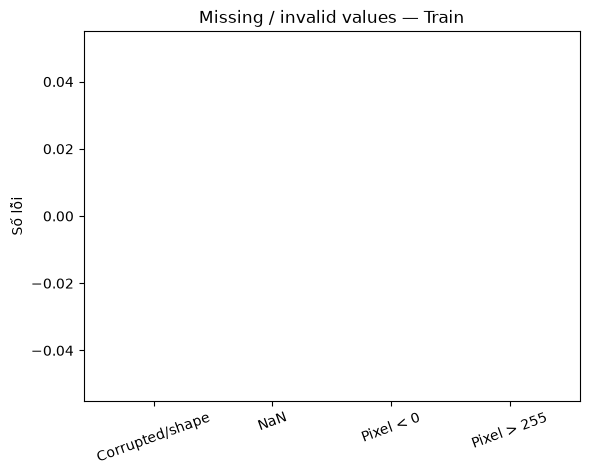

In [1]:
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd().parents[1] if Path.cwd().name == "Feature engineering" else Path.cwd()
TRAIN_DIR = ROOT / "Model" / "Dataset" / "Split data" / "Figures" / "Train"
records, invalid = [], []
for p in sorted(TRAIN_DIR.glob("*.png")):
    try:
        with Image.open(p) as im: a = np.asarray(im.convert("L"))
        if a.shape != (28, 28): raise ValueError(f"shape={a.shape}")
        records.append((p, int(p.name.split("_", 1)[0]), a))
    except Exception as e: invalid.append((str(p), str(e)))
X_raw = np.stack([r[2] for r in records]); y_train = np.array([r[1] for r in records])
issues = {"Corrupted/shape": len(invalid), "NaN": int(np.isnan(X_raw).sum()),
          "Pixel < 0": int((X_raw < 0).sum()), "Pixel > 255": int((X_raw > 255).sum())}
print(f"Train: {X_raw.shape}, dtype={X_raw.dtype}", issues)
plt.bar(list(issues), list(issues.values()), color="#E45756"); plt.title("Missing / invalid values — Train")
plt.ylabel("Số lỗi"); plt.xticks(rotation=20); plt.show()

## 1.2 Missing Value Handling Decision

**What:** Quyết định cách xử lý missing/invalid values dựa trên kiểm tra thực tế.

**Why:** không nên thêm imputation khi dữ liệu ảnh Train đã đầy đủ và hợp lệ.

**How:** giữ ảnh hợp lệ, không impute; nếu ảnh hỏng xuất hiện về sau thì loại tại bước validation đầu vào.

Decision: NO IMPUTATION


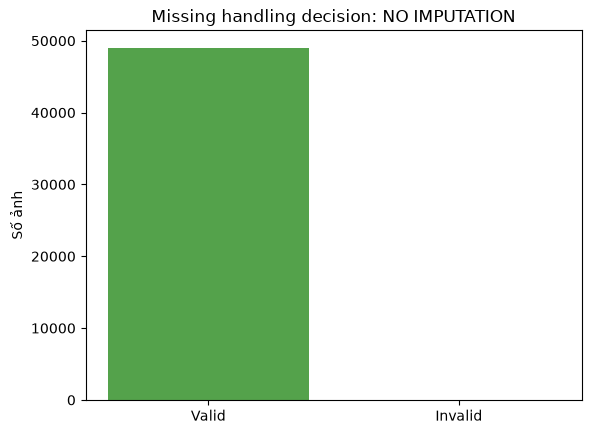

In [2]:
missing_total = sum(issues.values())
decision = "NO IMPUTATION" if missing_total == 0 else "REMOVE INVALID IMAGES"
print("Decision:", decision)
plt.bar(["Valid", "Invalid"], [len(X_raw), len(invalid)], color=["#54A24B", "#E45756"])
plt.title(f"Missing handling decision: {decision}"); plt.ylabel("Số ảnh"); plt.show()

# 2. Handling Outliers
## 2.1 Outlier Identification

**What:** Nhận diện ảnh bất thường theo mean và standard deviation pixel.

**Why:** ảnh quá tối, quá sáng hoặc có độ tương phản khác thường cần được xem trước khi quyết định loại.

**How:** tính robust z-score theo median/MAD trên Train và đánh dấu khi score lớn hơn 5.

Outliers: 3 (0.01%)


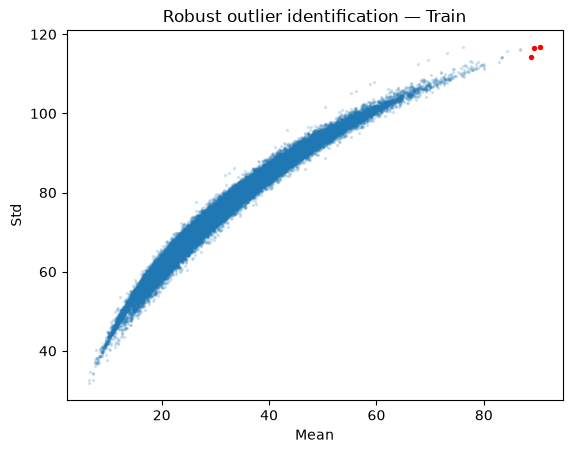

In [3]:
flat_raw = X_raw.reshape(len(X_raw), -1); image_mean = flat_raw.mean(1); image_std = flat_raw.std(1)
def robust_z(v):
    med = np.median(v); mad = np.median(np.abs(v-med))
    return .6745 * np.abs(v-med) / (mad or 1)
outlier_score = np.maximum(robust_z(image_mean), robust_z(image_std)); outlier_mask = outlier_score > 5
print(f"Outliers: {outlier_mask.sum():,} ({outlier_mask.mean():.2%})")
plt.scatter(image_mean[~outlier_mask], image_std[~outlier_mask], s=2, alpha=.15)
plt.scatter(image_mean[outlier_mask], image_std[outlier_mask], s=8, c="red")
plt.title("Robust outlier identification — Train"); plt.xlabel("Mean"); plt.ylabel("Std"); plt.show()

## 2.2 Visual Outlier Inspection

**What:** Quan sát trực tiếp các ảnh thực sự vượt ngưỡng outlier.

**Why:** chỉ ảnh có robust score lớn hơn 5 mới được xem là outlier thống kê; không hiển thị thêm ảnh dưới ngưỡng.

**How:** dùng `np.flatnonzero(outlier_mask)` và hiển thị toàn bộ ảnh bị gắn cờ cùng nhãn và score.

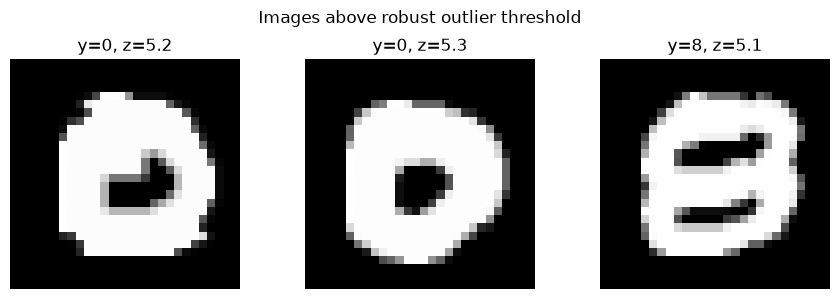

In [4]:
outlier_idx = np.flatnonzero(outlier_mask)
fig, axes = plt.subplots(1, max(1, len(outlier_idx)), figsize=(3*max(1, len(outlier_idx)), 3))
axes = np.atleast_1d(axes)
if len(outlier_idx):
    for i, ax in zip(outlier_idx, axes):
        ax.imshow(X_raw[i], cmap="gray"); ax.set_title(f"y={y_train[i]}, z={outlier_score[i]:.1f}"); ax.axis("off")
else:
    axes[0].text(.5, .5, "Không có outlier", ha="center", va="center"); axes[0].axis("off")
plt.suptitle("Images above robust outlier threshold"); plt.tight_layout(); plt.show()

## 2.3 Keep / Remove Decision

**What:** Chọn giữ hay loại các ảnh bị gắn cờ outlier.

**Why:** không có bằng chứng ảnh bất thường là sai nhãn; loại tự động có thể xóa kiểu viết hợp lệ hiếm.

**How:** giữ toàn bộ ảnh hợp lệ và chỉ lưu `outlier_mask` làm tín hiệu audit, không dùng để lọc Train.

Decision: KEEP ALL VALID IMAGES; outlier flag is audit-only


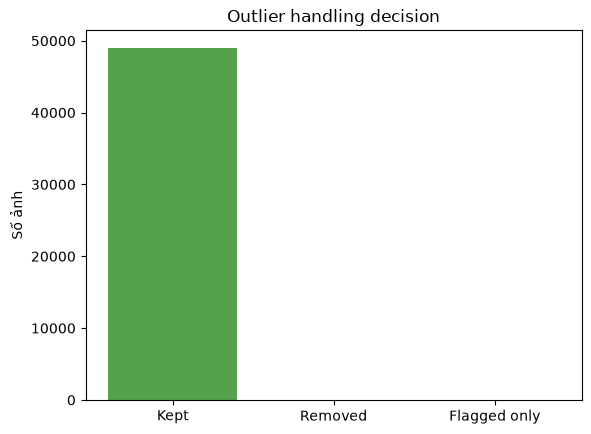

In [5]:
keep_mask = np.ones(len(X_raw), dtype=bool)
print("Decision: KEEP ALL VALID IMAGES; outlier flag is audit-only")
plt.bar(["Kept", "Removed", "Flagged only"], [keep_mask.sum(), 0, outlier_mask.sum()],
        color=["#54A24B", "#E45756", "#F58518"])
plt.title("Outlier handling decision"); plt.ylabel("Số ảnh"); plt.show()

# 3. Categorical Encoding
## 3.1 Categorical Input Feature Check

**What:** Kiểm tra có categorical input feature hay không.

**Why:** encoder chỉ cần thiết cho feature phân loại, không phải pixel số.

**How:** xác nhận 784 input feature đều là giá trị pixel số; tên file và path không đi vào model.

{'Numerical pixels': 784, 'Categorical inputs': 0}


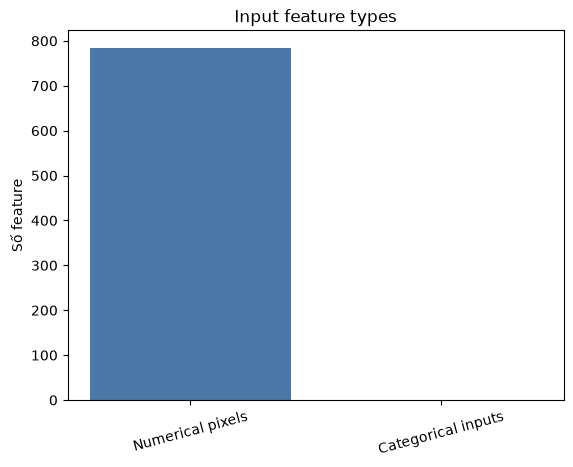

In [6]:
feature_types = {"Numerical pixels": 784, "Categorical inputs": 0}
print(feature_types)
plt.bar(list(feature_types), list(feature_types.values()), color=["#4C78A8", "#F58518"])
plt.title("Input feature types"); plt.ylabel("Số feature"); plt.xticks(rotation=15); plt.show()

## 3.2 Target Encoding Check — No Encoding Required

**What:** Kiểm tra kiểu và miền giá trị target.

**Why:** nhãn đã là integer 0–9 nên không cần LabelEncoder hoặc one-hot cho scikit-learn classifier.

**How:** xác nhận tập nhãn và trực quan hóa số lượng từng lớp trên Train.

Target: [0 1 2 3 4 5 6 7 8 9] | dtype: int64 | NO ENCODING REQUIRED: True


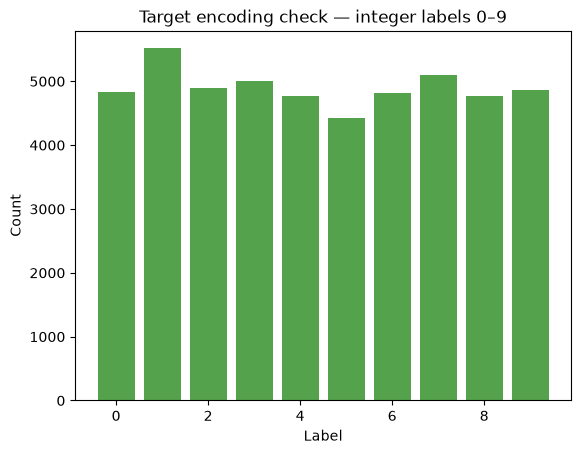

In [7]:
target_values = np.unique(y_train); target_ok = np.array_equal(target_values, np.arange(10))
print("Target:", target_values, "| dtype:", y_train.dtype, "| NO ENCODING REQUIRED:", target_ok)
plt.bar(target_values, np.bincount(y_train, minlength=10), color="#54A24B")
plt.title("Target encoding check — integer labels 0–9"); plt.xlabel("Label"); plt.ylabel("Count"); plt.show()

# 4. Numerical Transformation & Scaling
## 4.1 Vector Representation

**What:** Chuyển ảnh 28×28 thành vector 784 chiều.

**Why:** Logistic Regression nhận ma trận `(samples, features)`.

**How:** flatten theo row-major, giữ ánh xạ `pixel_index = row × 28 + col`.

Image: (49000, 28, 28) → Vector: (49000, 784)


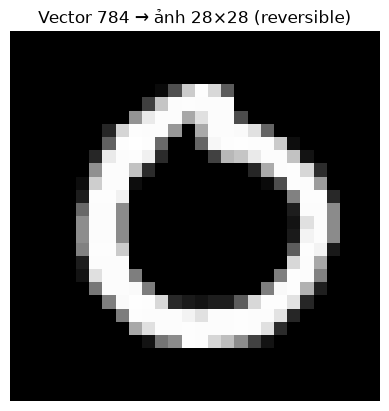

In [8]:
X_vector = X_raw.reshape(len(X_raw), 784)
print("Image:", X_raw.shape, "→ Vector:", X_vector.shape)
plt.imshow(X_vector[0].reshape(28, 28), cmap="gray"); plt.title("Vector 784 → ảnh 28×28 (reversible)")
plt.axis("off"); plt.show()

## 4.2 Pixel Normalization

**What:** Chuẩn hóa pixel từ `[0,255]` về `[0,1]`.

**Why:** thang đo ổn định cho Logistic Regression, giảm phụ thuộc đơn vị mà không làm mất cấu trúc ảnh.

**How:** chia cho 255 và lưu `float32`; phép biến đổi không fit tham số từ Test.

dtype=float32, range=(0.0, 1.0)


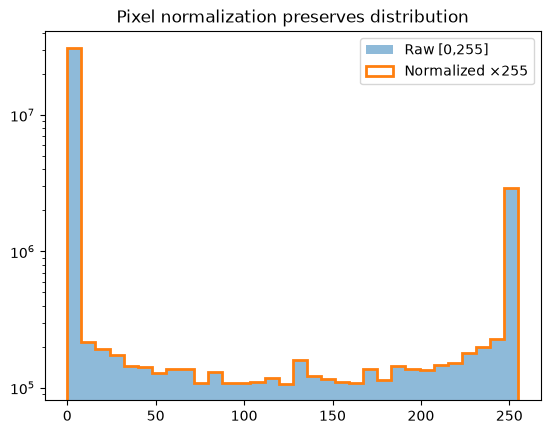

In [9]:
X_features = X_vector.astype(np.float32) / 255.0
print(f"dtype={X_features.dtype}, range=({X_features.min():.1f}, {X_features.max():.1f})")
plt.hist(X_vector.ravel(), bins=32, alpha=.5, label="Raw [0,255]")
plt.hist((X_features.ravel()*255), bins=32, histtype="step", lw=2, label="Normalized ×255")
plt.title("Pixel normalization preserves distribution"); plt.yscale("log"); plt.legend(); plt.show()

## 4.3 Post-transformation Validation

**What:** Kiểm tra shape, dtype, range, NaN và tính bảo toàn sau normalization.

**Why:** phát hiện lỗi transformation trước modeling.

**How:** assert các data contract và đo sai số round-trip về `uint8`.

{'shape 49k×784': True, 'float32': True, 'range [0,1]': np.True_, 'no NaN': True, 'round-trip exact': True}


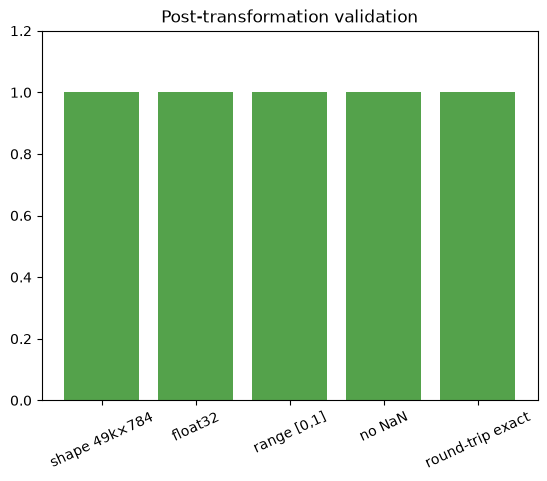

In [10]:
roundtrip = np.rint(X_features * 255).astype(np.uint8)
checks = {"shape 49k×784": X_features.shape == (len(X_raw), 784), "float32": X_features.dtype == np.float32,
          "range [0,1]": X_features.min() >= 0 and X_features.max() <= 1,
          "no NaN": not np.isnan(X_features).any(), "round-trip exact": np.array_equal(roundtrip, X_vector)}
print(checks); assert all(checks.values())
plt.bar(list(checks), [int(v) for v in checks.values()], color="#54A24B")
plt.ylim(0,1.2); plt.title("Post-transformation validation"); plt.xticks(rotation=25); plt.show()

## 4.4 StandardScaler Transformation Check — Optional

**What:** Kiểm tra phép biến đổi StandardScaler trên mẫu Train cố định.

**Why:** xác nhận scaler tạo feature có mean xấp xỉ 0 và standard deviation xấp xỉ 1; chưa có model nên chưa kết luận scaler cải thiện Logistic Regression.

**How:** fit trên 5.000 Train samples và chỉ kiểm tra các pixel có variance; so sánh model thật được chuyển sang Modeling.

Variable pixels in 5k sample: 656/784 | scaled mean=-0.000, std=1.000


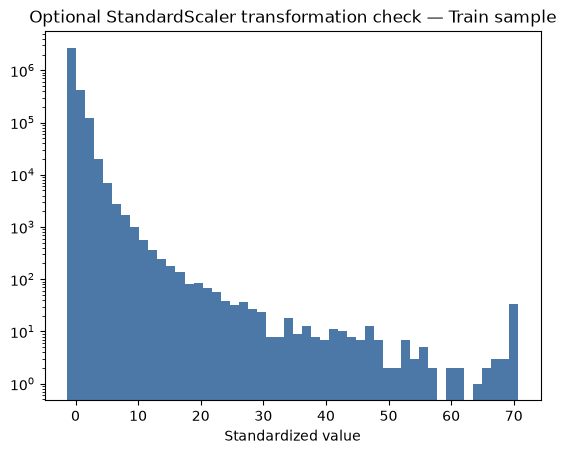

In [11]:
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(42); sample_idx = rng.choice(len(X_features), 5000, replace=False)
variable = X_features[sample_idx].var(0) > 0
scaled_sample = StandardScaler().fit_transform(X_features[sample_idx][:, variable])
print(f"Variable pixels in 5k sample: {variable.sum()}/784 | scaled mean={scaled_sample.mean():.3f}, std={scaled_sample.std():.3f}")
plt.hist(scaled_sample.ravel(), bins=50, log=True, color="#4C78A8")
plt.title("Optional StandardScaler transformation check — Train sample"); plt.xlabel("Standardized value"); plt.show()

# 5. Feature Creation / Generation
## 5.1 Raw Pixel Features

**What:** Định nghĩa 784 normalized raw pixels là feature set mặc định.

**Why:** giữ toàn bộ thông tin không gian gốc và tạo baseline trực tiếp, đơn giản cho Logistic Regression.

**How:** dùng `X_features` với tên `pixel_r_c`; chưa thêm feature suy diễn vào pipeline mặc định.

Default feature matrix: (49000, 784) | first/last: ['pixel_0_0' 'pixel_27_27']


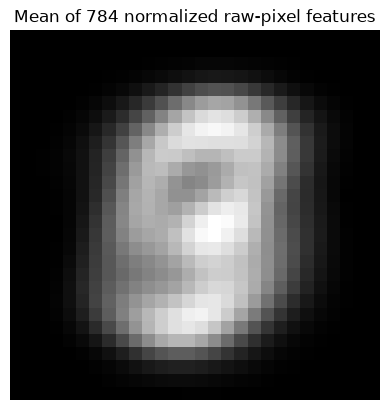

In [12]:
feature_names = np.array([f"pixel_{r}_{c}" for r in range(28) for c in range(28)])
print("Default feature matrix:", X_features.shape, "| first/last:", feature_names[[0,-1]])
plt.imshow(X_features.mean(0).reshape(28,28), cmap="gray")
plt.title("Mean of 784 normalized raw-pixel features"); plt.axis("off"); plt.show()

## 5.2 Spatial Preprocessing / Centering

**What:** Thử centering ảnh theo center of mass trên mẫu Train.

**Why:** centering có thể giảm translation variance nhưng chưa được chọn cho final pipeline.

**How:** dịch tối đa theo center of mass bằng SciPy trên 20 ảnh minh họa. Nếu được chọn sau Modeling, cùng một function và tham số bắt buộc áp dụng nhất quán cho Train, Test và input user khi deploy.

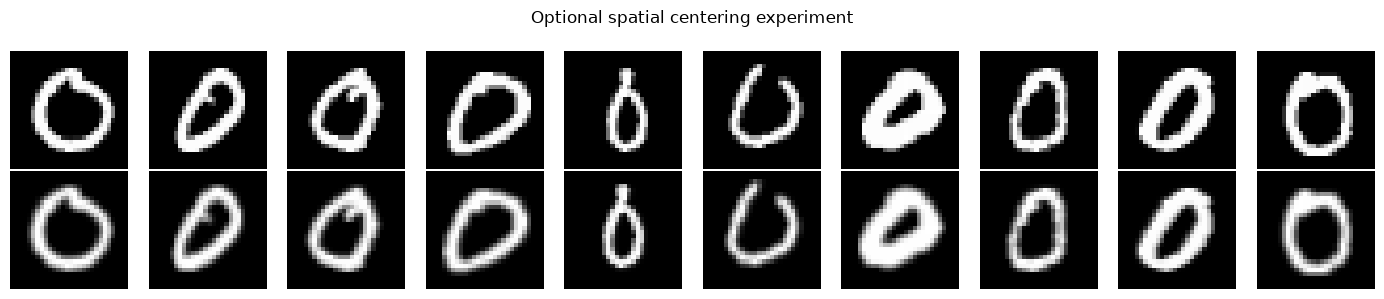

In [13]:
from scipy.ndimage import center_of_mass, shift
centered = []
for image in X_raw[:20]:
    cy, cx = center_of_mass(image); centered.append(shift(image, (13.5-cy, 13.5-cx), order=1, mode="constant"))
fig, ax = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    ax[0,i].imshow(X_raw[i], cmap="gray"); ax[1,i].imshow(centered[i], cmap="gray")
    ax[0,i].axis("off"); ax[1,i].axis("off")
ax[0,0].set_ylabel("Raw"); ax[1,0].set_ylabel("Centered")
plt.suptitle("Optional spatial centering experiment"); plt.tight_layout(); plt.show()

## 5.3 Handcrafted Features — Optional

**What:** Thử bốn feature tổng hợp: ink ratio, mean intensity, horizontal symmetry và vertical symmetry.

**Why:** feature thủ công có thể tăng khả năng giải thích nhưng chưa chứng minh cải thiện classification.

**How:** tính trên Train, quan sát mean theo lớp; không nối vào 784 feature mặc định.

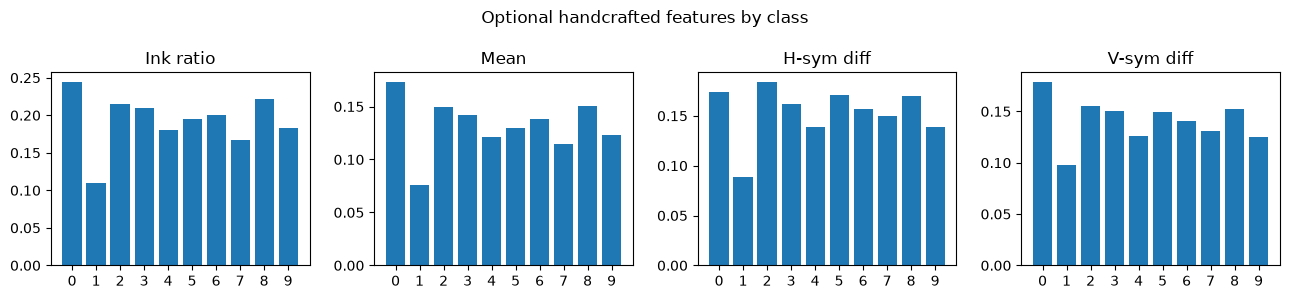

In [14]:
ink = (X_features > 0).mean(1); intensity = X_features.mean(1)
hsym = np.abs(X_features.reshape(-1,28,28) - X_features.reshape(-1,28,28)[:,::-1]).mean((1,2))
vsym = np.abs(X_features.reshape(-1,28,28) - X_features.reshape(-1,28,28)[:,:,::-1]).mean((1,2))
handcrafted = np.column_stack([ink, intensity, hsym, vsym]); names = ["Ink ratio","Mean","H-sym diff","V-sym diff"]
class_h = np.stack([handcrafted[y_train == d].mean(0) for d in range(10)])
fig, ax = plt.subplots(1,4,figsize=(13,3))
for j,a in enumerate(ax): a.bar(range(10),class_h[:,j]); a.set_title(names[j]); a.set_xticks(range(10))
plt.suptitle("Optional handcrafted features by class"); plt.tight_layout(); plt.show()

# 6. Feature Selection
## 6.1 Feature Variance Assessment

**What:** Đánh giá variance của 784 normalized pixels trên Train.

**Why:** pixel variance bằng 0 không phân biệt mẫu trong Train, nhưng có thể nhận tín hiệu khi deploy.

**How:** tính variance theo pixel và hiển thị variance map; chưa loại feature chỉ dựa trên Train variance.

Zero-variance pixels: 76/784


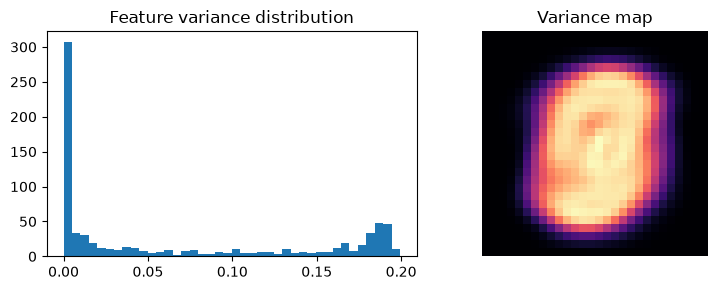

In [15]:
feature_variance = X_features.var(0); zero_variance = feature_variance == 0
print(f"Zero-variance pixels: {zero_variance.sum()}/784")
fig, ax = plt.subplots(1,2,figsize=(8,3))
ax[0].hist(feature_variance,bins=40); ax[0].set_title("Feature variance distribution")
ax[1].imshow(feature_variance.reshape(28,28),cmap="magma"); ax[1].set_title("Variance map"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 6.2 Correlation & Redundancy Assessment

**What:** Khảo sát Pearson correlation của 20 pixel có variance cao nhất trên Train.

**Why:** correlation cao gợi ý signal similarity/spatial redundancy, chưa đủ để kết luận feature vô ích hoặc multicollinearity toàn bộ 784 chiều.

**How:** tránh ma trận 784×784; chỉ trực quan hóa subset variance cao và không loại feature theo correlation.

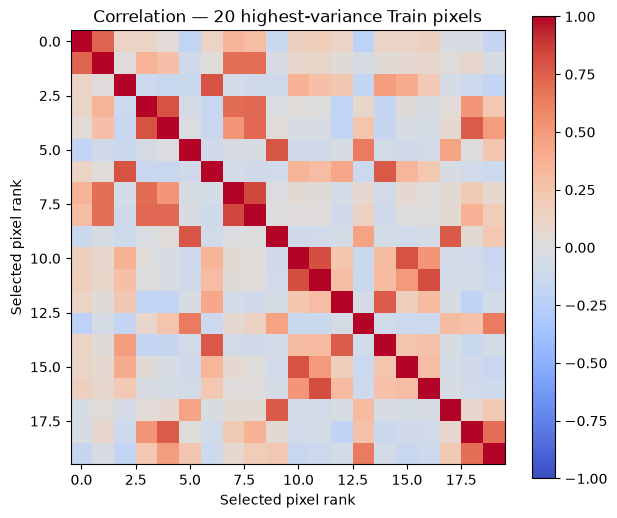

In [16]:
top20 = np.argsort(feature_variance)[-20:][::-1]
corr20 = np.corrcoef(X_features[:,top20], rowvar=False)
plt.figure(figsize=(7,6)); im=plt.imshow(corr20,vmin=-1,vmax=1,cmap="coolwarm")
plt.colorbar(im); plt.title("Correlation — 20 highest-variance Train pixels")
plt.xlabel("Selected pixel rank"); plt.ylabel("Selected pixel rank"); plt.show()

## 6.3 Deployment Shift / Input Sensitivity Assessment

**What:** Đo mức thay đổi của raw-pixel input trước brightness shift và dịch ảnh 1 pixel.

**Why:** phép đo MAE này chỉ chứng minh representation nhạy với input shift, không đo model robustness và không chứng minh giữ 784 feature giúp Logistic Regression chống dịch ảnh.

**How:** mô phỏng hai perturbation nhỏ trên 1.000 ảnh Train. Robustness thật phải được đánh giá trong Modeling bằng metric trên ảnh gốc và ảnh perturbation.

{'Brightness +0.1': 0.0896, 'Shift right 1px': 0.0824}


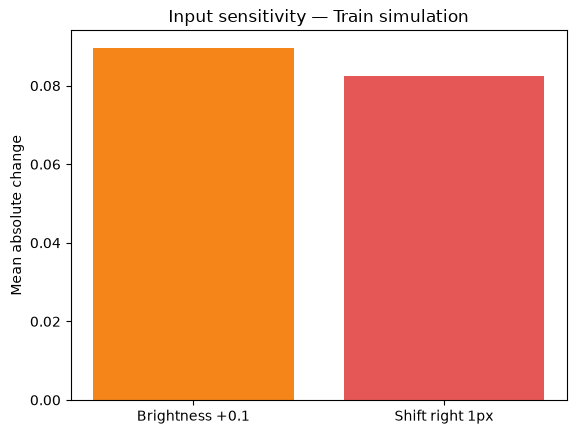

Conclusion: raw pixels are shift-sensitive; deployment preprocessing must be evaluated in Modeling.


In [17]:
probe = X_features[:1000].reshape(-1,28,28)
bright = np.clip(probe + .1, 0, 1); shifted = np.roll(probe, 1, axis=2); shifted[:,:,0] = 0
risk = {"Brightness +0.1": np.abs(bright-probe).mean(), "Shift right 1px": np.abs(shifted-probe).mean()}
print({k: round(float(v),4) for k,v in risk.items()})
plt.bar(list(risk), list(risk.values()), color=["#F58518","#E45756"])
plt.title("Input sensitivity — Train simulation"); plt.ylabel("Mean absolute change"); plt.show()
print("Conclusion: raw pixels are shift-sensitive; deployment preprocessing must be evaluated in Modeling.")

## 6.4 Feature Retention Decision — RETAIN ALL 784 FEATURES

**What:** Chốt feature set baseline gồm toàn bộ 784 normalized raw pixels.

**Why:** 784 feature vẫn là dimensionality nhỏ đối với Logistic Regression và chưa có bằng chứng thực nghiệm rằng feature removal cải thiện model. Giữ tất cả pixel không đảm bảo robustness trước translation shift; vấn đề đó phải được xử lý riêng bằng spatial preprocessing hoặc data augmentation.

**How:** giữ nguyên `X_features` cho baseline dễ giải thích; so sánh feature removal và robustness được chuyển sang Modeling.

DECISION: RETAIN ALL 784 FEATURES (49000, 784) float32


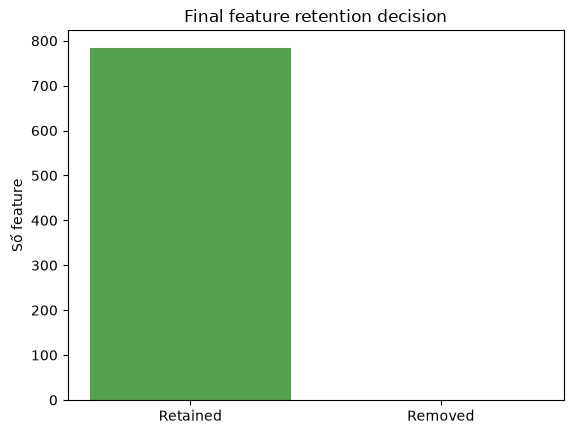

In [18]:
X_final = X_features; final_feature_names = feature_names
assert X_final.shape[1] == 784
print("DECISION: RETAIN ALL 784 FEATURES", X_final.shape, X_final.dtype)
plt.bar(["Retained", "Removed"], [X_final.shape[1], 0], color=["#54A24B", "#E45756"])
plt.title("Final feature retention decision"); plt.ylabel("Số feature"); plt.show()

## 6.5 Feature Selection Experiment — Optional

**What:** Thử xếp hạng các pixel có variance lớn hơn 0 bằng ANOVA F-score trên mẫu Train.

**Why:** pixel constant làm ANOVA sinh warning và không cung cấp F-score hữu ích; thử nghiệm này không thay đổi baseline 784 feature.

**How:** lọc constant pixel trong mẫu trước `f_classif`, ánh xạ score về đủ 784 vị trí và minh họa top 100 pixel.

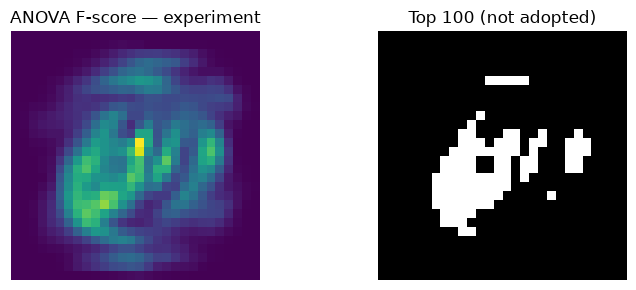

ANOVA variable pixels in 5k sample: 655/784; final retained: 784


In [19]:
from sklearn.feature_selection import f_classif
exp_idx = rng.choice(len(X_features), 5000, replace=False)
X_exp, y_exp = X_features[exp_idx], y_train[exp_idx]
variable_mask = X_exp.var(axis=0) > 0
f_score = np.zeros(784)
f_score[variable_mask], _ = f_classif(X_exp[:, variable_mask], y_exp)
f_score = np.nan_to_num(f_score)
top100 = np.argsort(f_score)[-100:]
selected_map = np.zeros(784); selected_map[top100] = 1
fig, ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(f_score.reshape(28,28),cmap="viridis"); ax[0].set_title("ANOVA F-score — experiment")
ax[1].imshow(selected_map.reshape(28,28),cmap="gray"); ax[1].set_title("Top 100 (not adopted)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print(f"ANOVA variable pixels in 5k sample: {variable_mask.sum()}/784; final retained: {X_final.shape[1]}")

## 6.6 Save Feature Engineering Output

**What:** Lưu feature matrix, target và feature names để Modeling load trực tiếp.

**Why:** tạo data contract rõ ràng giữa Feature Engineering và Modeling, tránh chạy lại xử lý ảnh trong bước model.

**How:** lưu ba file `.npy` vào `Vectors/Train`, đọc lại bằng memory map và xác minh shape, dtype, tên feature cùng nội dung trước khi báo thành công.

Saved and verified:

 {'X_train_fe.npy': ((49000, 784), 'float32'), 'y_train.npy': ((49000,), 'int64'), 'feature_names.npy': ((784,), '<U11')}


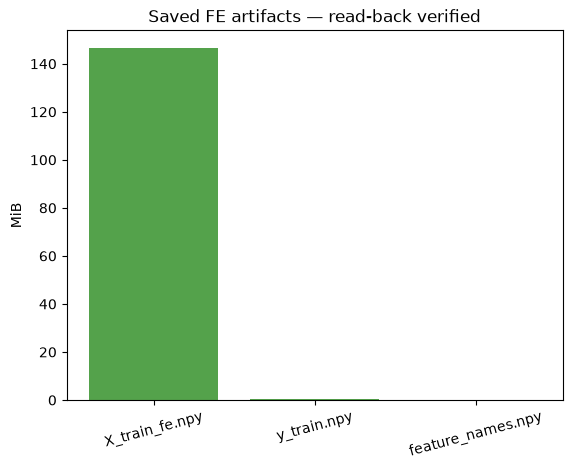

In [20]:
OUTPUT_DIR = ROOT / "Model" / "Dataset" / "Split data" / "Vectors" / "Train"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
outputs = {"X_train_fe.npy": X_final, "y_train.npy": y_train, "feature_names.npy": final_feature_names}
for name, array in outputs.items(): np.save(OUTPUT_DIR / name, array)
loaded = {name: np.load(OUTPUT_DIR / name, mmap_mode="r") for name in outputs}
assert loaded["X_train_fe.npy"].shape == (49000, 784) and loaded["X_train_fe.npy"].dtype == np.float32
assert loaded["y_train.npy"].shape == (49000,) and np.array_equal(loaded["y_train.npy"], y_train)
assert loaded["feature_names.npy"].shape == (784,) and np.array_equal(loaded["feature_names.npy"], final_feature_names)
assert np.array_equal(loaded["X_train_fe.npy"], X_final)
sizes = {name: (OUTPUT_DIR/name).stat().st_size / 2**20 for name in outputs}
print("Saved and verified:", {k: (v.shape, str(v.dtype)) for k,v in loaded.items()})
plt.bar(list(sizes), list(sizes.values()), color="#54A24B"); plt.ylabel("MiB")
plt.title("Saved FE artifacts — read-back verified"); plt.xticks(rotation=15); plt.show()